# Intelligent Customer Churn Prediction & Retention Optimization System

**Week 2: Advanced Data Visualization and Storytelling with Python**

Internship: Virtual Data Science with Python Apprentice Internship

Tools: Python, Pandas, NumPy, Matplotlib, Seaborn

Dataset: IBM Telco Customer Churn Dataset

Objective:
This week focuses on transforming the findings from Week 1 exploratory analysis into a clear and meaningful visual data story. The analysis uses advanced visualization techniques to communicate customer churn patterns, relationships, and business implications to a non-technical audience.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Preparation

### Dataset Selection

The dataset selected for this project is the IBM Telco Customer Churn dataset.

The dataset contains customer-level information related to demographics,
telecommunication services, account information, billing details, tenure,
and customer churn status.

This dataset was selected because customer churn is a realistic business
problem and the dataset contains both numerical and categorical variables.
It is therefore suitable for data cleaning, exploratory analysis,
statistical analysis, and machine learning in the later stages of this
five-week project.

### Dataset Source

IBM GitHub Repository:
https://github.com/IBM/telco-customer-churn-on-icp4d

The dataset will be acquired directly from the publicly available IBM
repository.

In [ ]:
# Load the IBM Telco Customer Churn dataset

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


In [19]:
# Prepare the dataset for Week 2 analysis

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Dataset prepared successfully!")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

Dataset prepared successfully!
Shape: (7043, 22)
Missing values: 0


In [ ]:
# Clean TotalCharges, as done in Week 1

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("TotalCharges cleaned successfully!")
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

TotalCharges cleaned successfully!
Missing values in TotalCharges: 0


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [ ]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Series([], dtype: int64)


In [ ]:
# Missing-value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Columns with missing values:")
print(missing_percentage[missing_percentage > 0])

Columns with missing values:
Series([], dtype: float64)


In [ ]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Check for duplicate customer IDs
duplicate_customer_ids = df["customerID"].duplicated().sum()

print("Duplicate customer IDs:", duplicate_customer_ids)

Duplicate customer IDs: 0


In [ ]:
# Inspect unique values that may cause TotalCharges to be non-numeric
print(df["TotalCharges"].unique()[:20])

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']


In [ ]:
# Find blank values in TotalCharges
blank_total_charges = df["TotalCharges"].astype(str).str.strip().eq("").sum()

print("Blank TotalCharges values:", blank_total_charges)

Blank TotalCharges values: 11


In [ ]:
# Display rows where TotalCharges is blank
df[df["TotalCharges"].astype(str).str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
# Display unique values for categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

TotalCharges:
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Churn:
['No' 'Yes']


In [ ]:
# Summary of numerical variables
df.select_dtypes(include=np.number).describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [ ]:
## 3. Data Cleaning and Preprocessing

Based on the initial data-quality audit, the dataset contained no duplicate rows or duplicate customer IDs. However, the `TotalCharges` column was stored as an object datatype instead of a numeric datatype, and 11 records contained blank values.

The blank `TotalCharges` values correspond to customers with zero months of tenure. Since these customers have just started their service, replacing their total charges with an arbitrary statistical value such as the mean could distort the data. Therefore, the blank values will be treated as missing values and replaced with 0, which is logically consistent with zero accumulated tenure.

The `TotalCharges` column will then be converted to a numeric datatype for accurate statistical analysis and visualization.

In [ ]:
# Replace blank TotalCharges values with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Check the number of missing values
print("Missing TotalCharges after conversion:",
      df["TotalCharges"].isnull().sum())

Missing TotalCharges after conversion: 11


In [ ]:
# Convert TotalCharges from object to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

print("TotalCharges datatype:", df["TotalCharges"].dtype)

TotalCharges datatype: float64


In [ ]:
# Fill missing TotalCharges with 0 for customers with zero tenure
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing TotalCharges after cleaning:",
      df["TotalCharges"].isnull().sum())

Missing TotalCharges after cleaning: 0


In [ ]:
# Verify data types after cleaning
print("Updated data types:")
print(df.dtypes)

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

print("\nDataset shape:")
print(df.shape)

Updated data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing values after cleaning:
0

Dataset shape:
(7043, 21)


In [ ]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [ ]:
## 4. Exploratory Data Analysis (EDA)

After cleaning the dataset, exploratory data analysis is performed to understand customer characteristics, service usage, billing patterns, and churn distribution.

The analysis focuses on identifying important patterns and relationships that may help explain why customers leave the service.

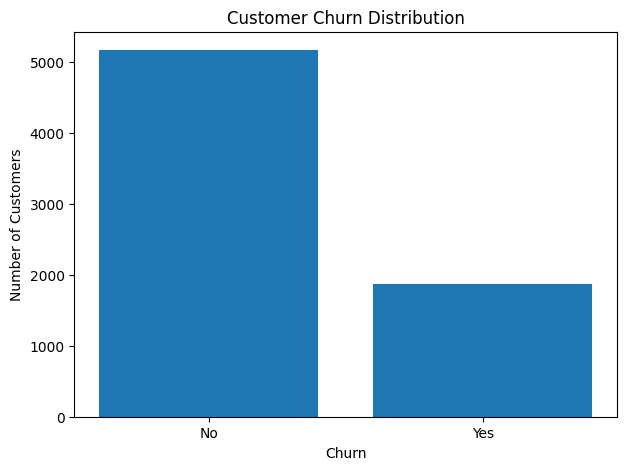

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
# Churn distribution

import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(churn_counts.index, churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

print("Churn distribution:")
print(churn_counts)

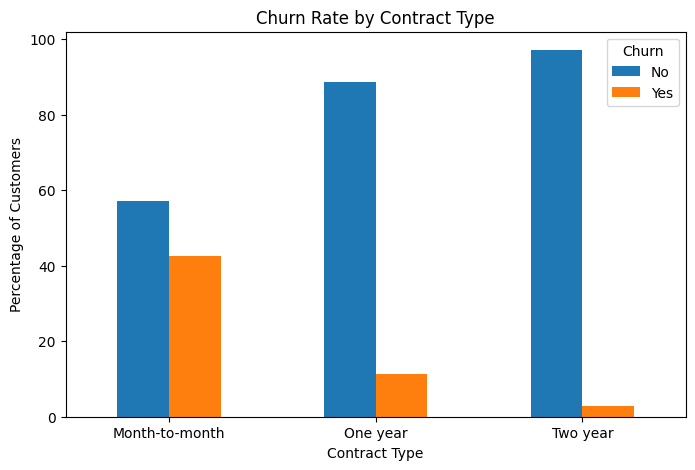

Churn rate by contract type (%):
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


In [ ]:
# Churn rate by contract type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

print("Churn rate by contract type (%):")
print(contract_churn.round(2))

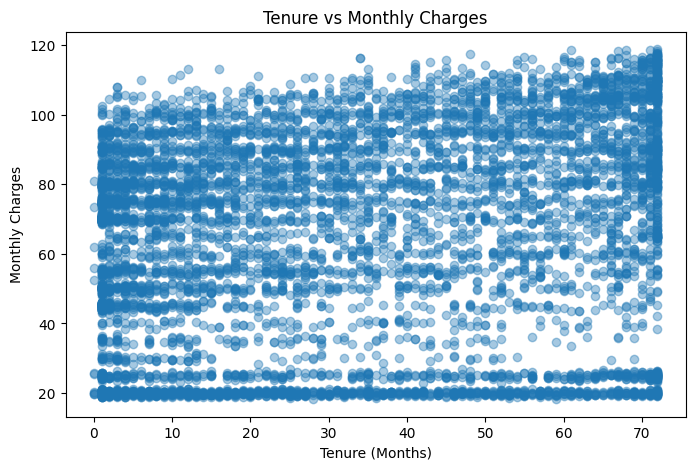

In [ ]:
# Relationship between tenure and monthly charges

plt.figure(figsize=(8, 5))

plt.scatter(
    df["tenure"],
    df["MonthlyCharges"],
    alpha=0.4
)

plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.show()

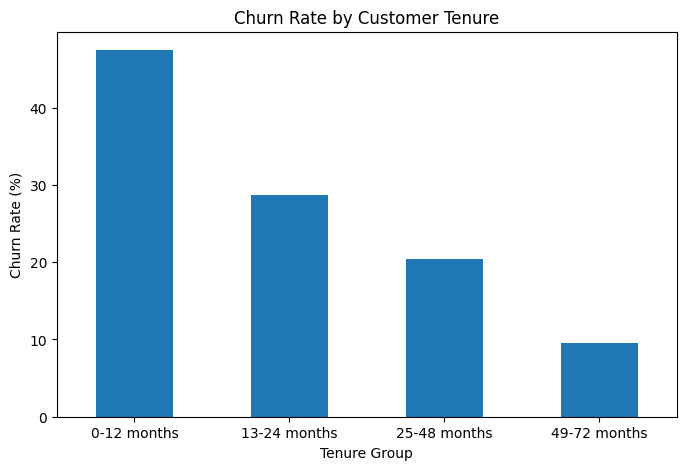

Churn rate by tenure group (%):
TenureGroup
0-12 months     47.44
13-24 months    28.71
25-48 months    20.39
49-72 months     9.51
Name: Yes, dtype: float64


In [ ]:
# Churn rate by tenure group

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

print("Churn rate by tenure group (%):")
print(tenure_churn["Yes"].round(2))

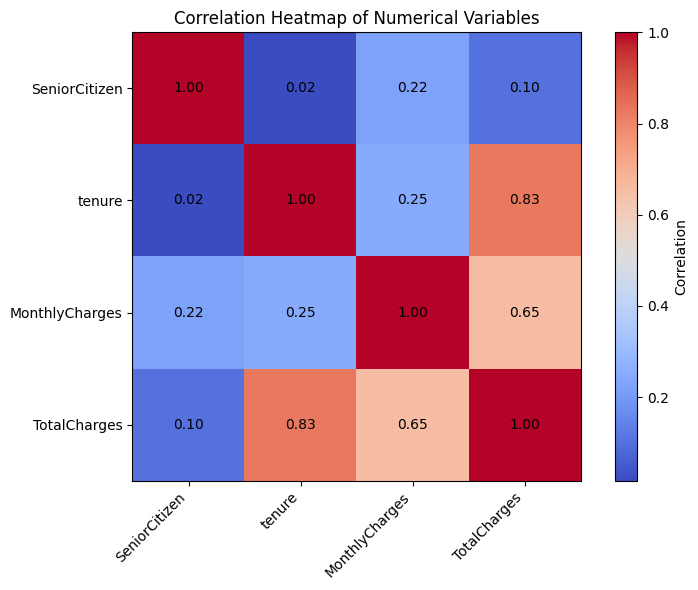

Correlation matrix:
                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen            1.00    0.02            0.22          0.10
tenure                   0.02    1.00            0.25          0.83
MonthlyCharges           0.22    0.25            1.00          0.65
TotalCharges             0.10    0.83            0.65          1.00


In [ ]:
# Correlation analysis of numerical variables

numeric_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title("Correlation Heatmap of Numerical Variables")

# Add correlation values
for i in range(len(numeric_columns)):
    for j in range(len(numeric_columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

print("Correlation matrix:")
print(correlation_matrix.round(2))

## Key Findings from Exploratory Data Analysis

- The dataset contains 7,043 customers and 21 variables.
- There are no duplicate customer IDs.
- Initially, 11 missing values were found in TotalCharges. These were cleaned and converted to numeric format.
- 1,869 customers have churned, while 5,174 have not churned.
- Month-to-month customers have the highest churn rate (42.71%).
- Customers with longer contracts have much lower churn rates.
- Customers with 0–12 months of tenure have the highest churn rate (47.44%).
- Tenure and TotalCharges have a strong positive correlation (0.83).
- MonthlyCharges and TotalCharges have a moderate positive correlation (0.65).

### Conclusion

The EDA indicates that contract type, customer tenure, and charges are important factors associated with customer churn.

# Week 2: Advanced Data Visualization and Storytelling

## Objective

This week focuses on transforming the findings from Week 1 exploratory data analysis into a clear and meaningful data story.

Using the cleaned IBM Telco Customer Churn dataset, advanced visualizations will be developed to identify important customer behavior patterns, churn drivers, relationships between variables, and potential business implications.

The visualizations will be designed not only to display data, but also to communicate insights clearly to a non-technical audience.

## 1. Visualization and Storytelling Approach

The Week 2 analysis builds upon the cleaned dataset prepared during Week 1.

The visualization process will follow these steps:

1. Identify important business questions related to customer churn.
2. Select appropriate variables for each question.
3. Choose visualization techniques that communicate the relationships clearly.
4. Add titles, labels, annotations, and captions to improve interpretation.
5. Extract key insights from each visualization.
6. Connect individual findings into a coherent customer churn story.
7. Translate the analytical findings into potential business recommendations.

In [8]:
# Visualization 1: Churn Rate by Contract Type

contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


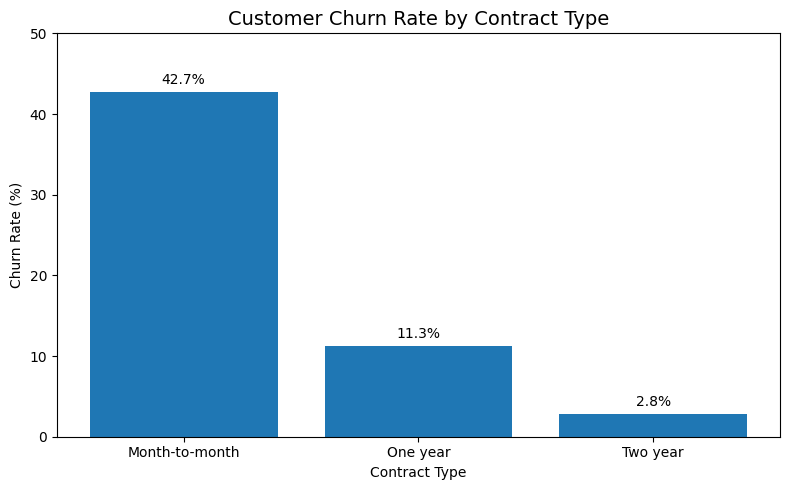

In [10]:
# Create a bar chart of churn rates

import matplotlib.pyplot as plt

churn_rates = contract_churn['Yes']

plt.figure(figsize=(8, 5))

bars = plt.bar(churn_rates.index, churn_rates.values)

plt.title('Customer Churn Rate by Contract Type', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.ylim(0, 50)

# Add percentage labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

**Visualization 1 — Business Insight**

Insight: Customers with month-to-month contracts have the highest churn rate at 42.7%, compared with 11.3% for one-year contracts and only 2.8% for two-year contracts. This shows a strong relationship between contract duration and customer retention.

Business implication: Month-to-month customers should be considered a high-priority segment for retention campaigns. The company could investigate incentives such as discounts, loyalty benefits, or contract-upgrade offers to encourage these customers to move to longer-term contracts.

Why this visualization was chosen: A bar chart makes it easy for a non-technical audience to compare churn rates across contract categories. The percentage annotations provide the exact values without requiring the reader to estimate them from the axis.


In [11]:
# Visualization 2: Churn Rate by Tenure Group

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 60, 72],
    labels=['0-12 months', '13-24 months', '25-48 months',
            '49-60 months', '61-72 months']
)

df[['tenure', 'TenureGroup']].head()

,tenure,TenureGroup
0,1,0-12 months
1,34,25-48 months
2,2,0-12 months
3,45,25-48 months
4,2,0-12 months


In [12]:
# Calculate churn rate for each tenure group

tenure_churn = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-60 months,85.576923,14.423077
61-72 months,93.390192,6.609808


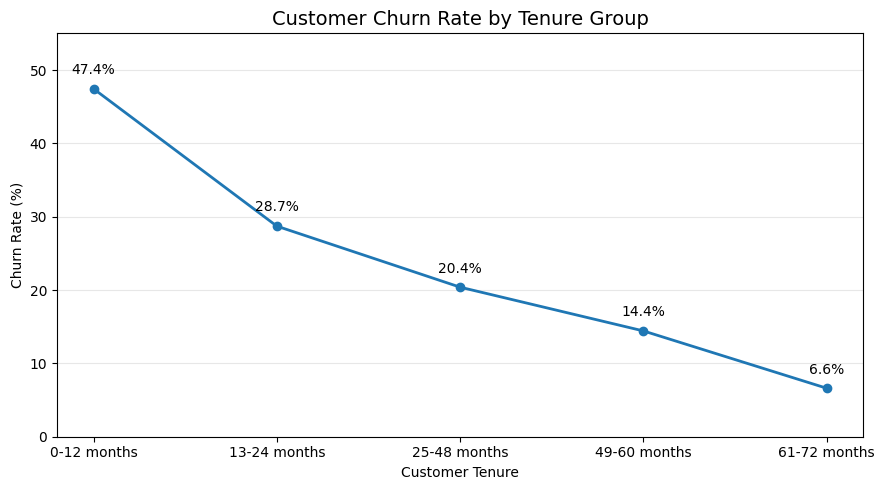

In [13]:
# Create a line chart of churn rate by tenure group

tenure_churn_rates = tenure_churn['Yes']

plt.figure(figsize=(9, 5))

plt.plot(
    tenure_churn_rates.index,
    tenure_churn_rates.values,
    marker='o',
    linewidth=2
)

plt.title('Customer Churn Rate by Tenure Group', fontsize=14)
plt.xlabel('Customer Tenure')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 55)

# Add percentage labels
for i, value in enumerate(tenure_churn_rates.values):
    plt.text(
        i,
        value + 2,
        f'{value:.1f}%',
        ha='center'
    )

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Visualization 2 — Business Insight**

Insight: Churn is highest among customers with 0–12 months of tenure, at 47.4%. The churn rate then steadily decreases across every subsequent tenure group, reaching only 6.6% among customers with 61–72 months of tenure. This indicates that newer customers are considerably more likely to leave than long-term customers.

Business implication: The company should prioritize retention during the early stages of the customer relationship. Improved onboarding, early engagement, proactive customer support, and targeted retention offers could help reduce early-stage churn.

Why this visualization was chosen: A line chart is appropriate because the tenure groups follow a natural progression from newer to older customers. The connected points make the downward trend in churn easy for a non-technical audience to recognize, while the percentage annotations show the exact values.

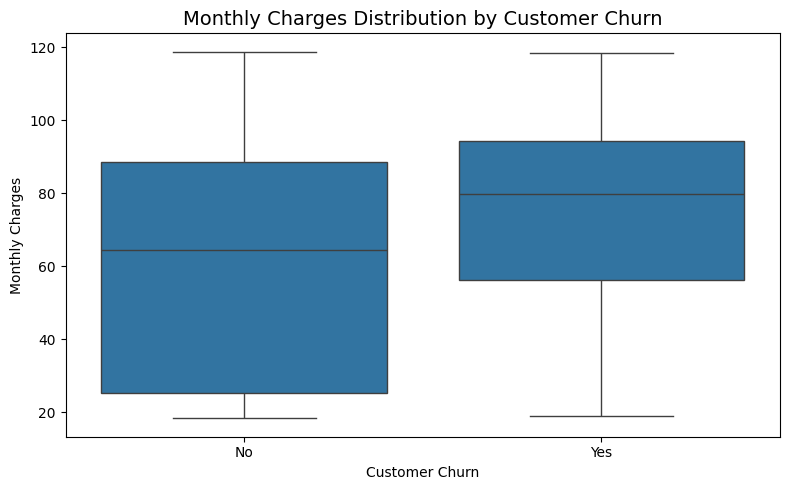

In [15]:
# Visualization 3: Monthly Charges Distribution by Churn

import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title('Monthly Charges Distribution by Customer Churn', fontsize=14)
plt.xlabel('Customer Churn')
plt.ylabel('Monthly Charges')

plt.tight_layout()
plt.show()

**Visualization 3 — Business Insight**

Insight: The box plot shows that customers who churn tend to have higher monthly charges than customers who remain with the company. The median monthly charge is approximately $80 for churned customers compared with approximately $65 for customers who stayed. The distribution for churned customers is therefore shifted toward higher monthly charges.

Business implication: Higher-charge customers may represent an important segment for retention analysis. The company could investigate whether customers paying more are receiving sufficient value from their services and consider targeted offers, service improvements, or personalized retention strategies. However, higher monthly charges should be treated as an associated factor rather than proof that pricing directly causes churn.

Why this visualization was chosen: A box plot was selected because it compares the distributions of monthly charges between customers who stayed and those who churned. Unlike a simple average, it shows the median, spread, and overall distribution, providing a more detailed view of differences between the two groups.

In [16]:
# Visualization 4: Churn Rate by Payment Method

payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


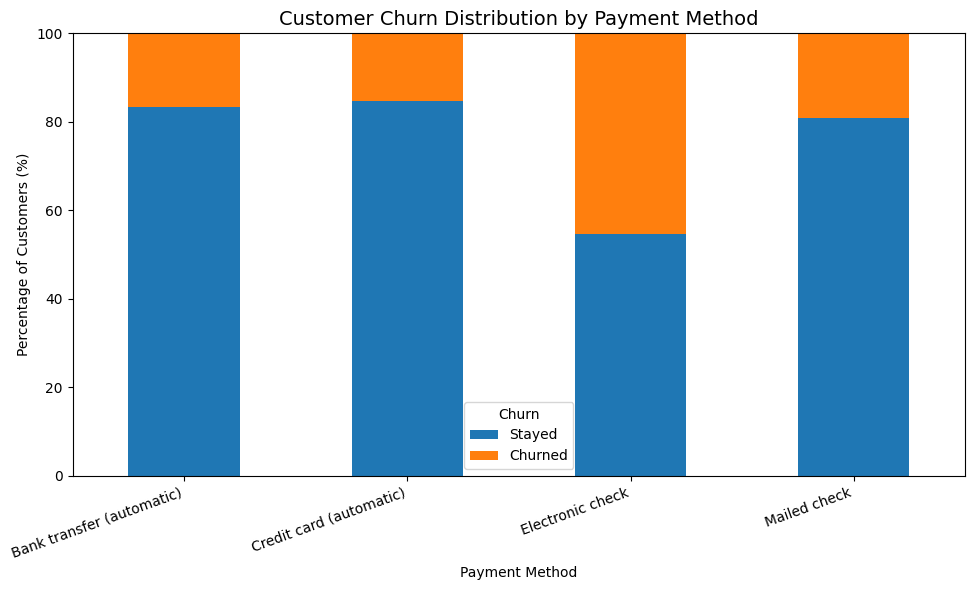

In [17]:
# Visualization 4: 100% Stacked Bar Chart

payment_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Customer Churn Distribution by Payment Method', fontsize=14)
plt.xlabel('Payment Method')
plt.ylabel('Percentage of Customers (%)')

plt.xticks(rotation=20, ha='right')
plt.ylim(0, 100)

plt.legend(
    title='Churn',
    labels=['Stayed', 'Churned']
)

plt.tight_layout()
plt.show()

**Visualization 4 — Business Insight**

Insight: The 100% stacked bar chart shows a substantial difference in churn across payment methods. Customers using electronic checks have a churn rate of 45.3%, considerably higher than customers using bank transfers (16.7%), credit cards (15.2%), or mailed checks (19.1%).

Business implication: Electronic-check customers should be considered a high-priority segment for further investigation and retention efforts. The company could examine whether payment experience, billing processes, customer demographics, or other service factors contribute to this higher churn rate. Payment method should be treated as an associated factor rather than evidence of causation.

Why this visualization was chosen: A 100% stacked bar chart allows each payment method to be treated as a complete 100% customer group. This makes it easy to compare the proportion of customers who stayed versus churned, even when the number of customers differs between payment methods.

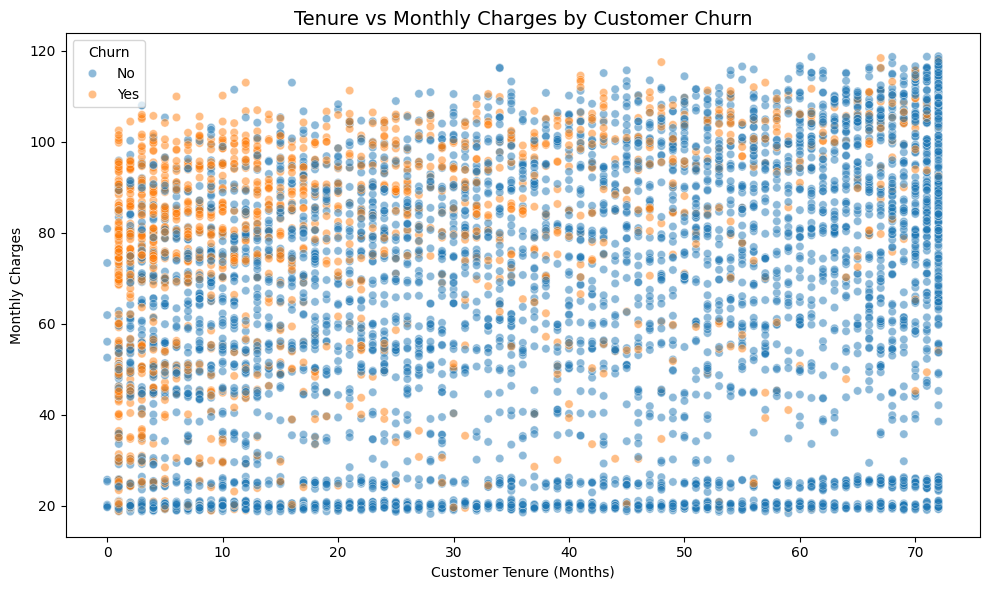

In [18]:
# Visualization 5: Tenure vs Monthly Charges by Churn

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    alpha=0.5
)

plt.title('Tenure vs Monthly Charges by Customer Churn', fontsize=14)
plt.xlabel('Customer Tenure (Months)')
plt.ylabel('Monthly Charges')

plt.legend(title='Churn')

plt.tight_layout()
plt.show()

**Visualization 5 — Business Insight**

Insight: The scatter plot combines customer tenure, monthly charges, and churn status to reveal patterns that are not as apparent when examining individual variables separately. Churned customers are particularly visible among customers with shorter tenure, while orange points also appear frequently in higher monthly-charge ranges. This suggests that customers who are newer to the company and paying relatively higher monthly charges may represent an important high-risk segment.

Business implication: Retention strategies could prioritize newer customers with relatively high monthly charges. The company could provide stronger onboarding, proactive customer support, personalized offers, and early engagement programs for this segment. Further analysis would be required to determine whether other factors, such as contract type or service usage, explain the observed relationship.

Why this visualization was chosen: A scatter plot is effective for examining relationships between two numerical variables while using color to represent a third variable. It allows individual customers to be viewed simultaneously and helps identify clusters and patterns that may be hidden in separate summary charts.

**Overall Data Story**

The visual analysis reveals that customer churn is concentrated among specific customer segments rather than being evenly distributed across the customer base. Contract type shows the strongest difference, with month-to-month customers having a churn rate of 42.7%, compared with 11.3% for one-year contracts and 2.8% for two-year contracts.

Customer tenure provides another important perspective. Churn is highest during the first 12 months, at 47.4%, and steadily decreases as customers remain with the company longer, reaching 6.6% among customers with 61–72 months of tenure. This indicates that the early customer lifecycle is a particularly important period for retention.

The monthly-charge analysis shows that churned customers tend to have higher monthly charges than customers who stay. The payment-method analysis also identifies electronic-check users as a high-risk segment, with a churn rate of 45.3%, substantially higher than the other payment groups.

Finally, the scatter plot combines tenure, monthly charges, and churn status. It suggests that shorter-tenure customers and customers with relatively higher monthly charges deserve closer attention. Taken together, the visualizations indicate that effective retention should focus on identifying high-risk customers early and understanding the combination of contract, tenure, charges, and payment behavior associated with churn.

**Business Recommendations**

Based on the visualization findings, the following strategies could help reduce customer churn:

1. Prioritize month-to-month customers: Since this group has substantially higher churn, the company could provide incentives for customers to move toward longer-term contracts.

2. Strengthen early customer retention: The first 12 months represent the highest-risk period. Improved onboarding, proactive support, satisfaction checks, and early engagement campaigns could help customers establish stronger relationships with the company.

3. Investigate high-charge customers: Customers with higher monthly charges appear more frequently among churned customers. The company should investigate whether these customers perceive insufficient value and consider personalized offers or service improvements.

4. Investigate electronic-check customers: The unusually high churn rate among electronic-check users warrants further investigation into billing experience, payment processes, and customer characteristics associated with this group.

5. Combine multiple risk factors: Instead of relying on a single characteristic, future retention systems could combine contract type, tenure, monthly charges, payment method, and other customer attributes to identify customers who may require proactive retention attention.

**Conclusion**

This Week 2 analysis used advanced data visualization and storytelling techniques to examine the factors associated with customer churn. Five different visualizations were developed using bar charts, line charts, box plots, stacked bar charts, and scatter plots. Each visualization was selected to communicate a specific business question clearly and make the findings understandable to a non-technical audience.

The analysis shows that churn is particularly concentrated among month-to-month customers, newer customers, customers with relatively higher monthly charges, and electronic-check users. The combined visual analysis also demonstrates that customer churn is influenced by multiple characteristics rather than a single factor.

These findings can support a more targeted customer-retention strategy. Instead of applying the same retention approach to every customer, the company can prioritize customers who display several high-risk characteristics. The insights from this analysis can also serve as a foundation for the next stage of the project: developing a machine-learning model that predicts which individual customers are most likely to churn.

Overall, the visualizations transform the raw customer data into a clear business story: customers are most vulnerable to churn during the early stages of their relationship, particularly when combined with other risk factors such as short-term contracts, higher monthly charges, and certain payment behaviors.